In [1]:
# Importing and loading cleaned data
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

# Loading the master table we built in last phase
master = pd.read_csv('../data/cleaned/master_analysis.csv')
w21    = pd.read_csv('../data/cleaned/winners_2021.csv')
w26    = pd.read_csv('../data/cleaned/winners_2026.csv')

# Making sure charts folder exists
os.makedirs('../charts', exist_ok=True)

print("Master shape:", master.shape)
print("All files loaded successfully")

Master shape: (234, 17)
All files loaded successfully


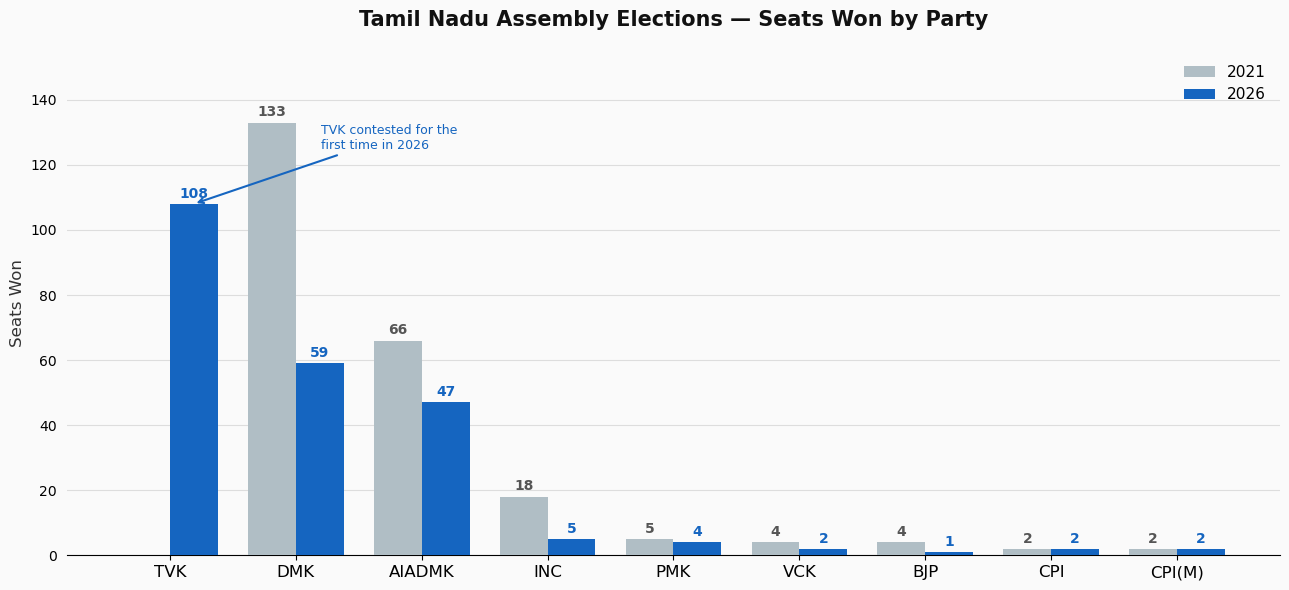

Chart 1 saved.


In [3]:
# Chart 1 — Seat count comparison 2021 vs 2026

# Defining the parties worth showing (ignoring tiny parties)
main_parties = ['TVK', 'DMK', 'AIADMK', 'INC', 'PMK', 'VCK', 'BJP', 'CPI', 'CPI(M)']

# Counting seats per party for each year
seats_21 = w21[w21['party'].isin(main_parties)]['party'].value_counts().reindex(main_parties, fill_value=0)
seats_26 = w26[w26['party'].isin(main_parties)]['party'].value_counts().reindex(main_parties, fill_value=0)

# Chart setup
fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

x      = np.arange(len(main_parties))
width  = 0.38

# Drawing bars
bars_21 = ax.bar(x - width/2, seats_21, width, color='#B0BEC5', label='2021', zorder=3)
bars_26 = ax.bar(x + width/2, seats_26, width, color='#1565C0', label='2026', zorder=3)

# Adding value labels on top of each bar
for bar in bars_21:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 1, str(int(h)),
                ha='center', va='bottom', fontsize=10, color='#555555', fontweight='bold')

for bar in bars_26:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 1, str(int(h)),
                ha='center', va='bottom', fontsize=10, color='#1565C0', fontweight='bold')

# Formatting
ax.set_xticks(x)
ax.set_xticklabels(main_parties, fontsize=12)
ax.set_ylabel('Seats Won', fontsize=12, color='#333333')
ax.set_ylim(0, 155)
ax.yaxis.grid(True, color='#DDDDDD', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.spines[['top','right','left']].set_visible(False)
ax.tick_params(left=False)

# Title and legend
ax.set_title('Tamil Nadu Assembly Elections — Seats Won by Party',
             fontsize=15, fontweight='bold', color='#111111', pad=18)
ax.legend(fontsize=11, frameon=False)

# Annotation for TVK context
ax.annotate('TVK contested for the\nfirst time in 2026',
            xy=(0 + width/2, 108), xytext=(1.2, 125),
            arrowprops=dict(arrowstyle='->', color='#1565C0', lw=1.5),
            fontsize=9, color='#1565C0')

plt.tight_layout()
plt.savefig('../charts/chart1_seat_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved.")

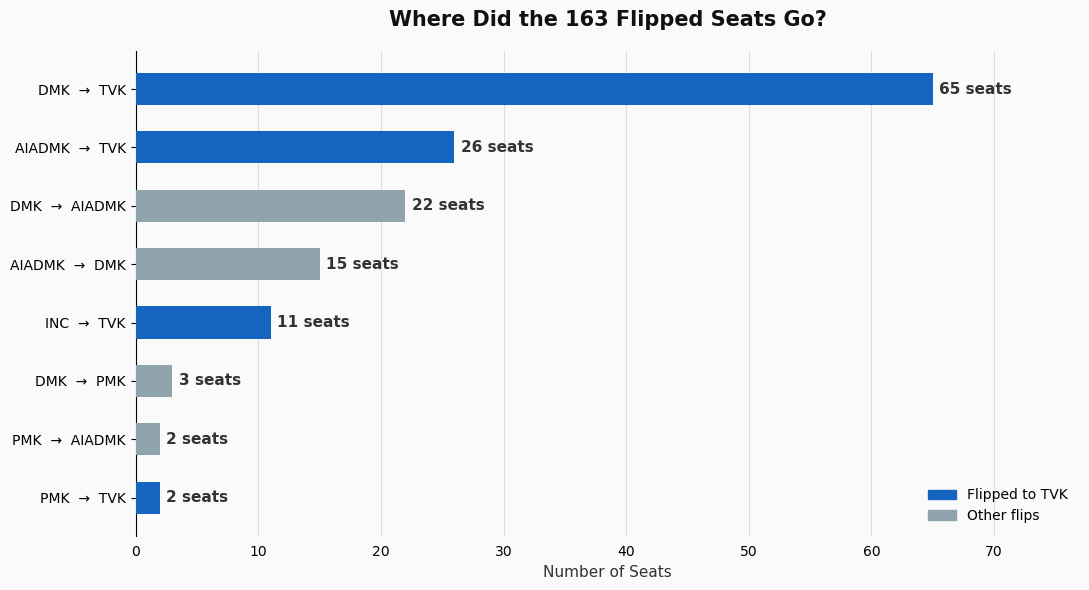

Chart 2 saved.


In [5]:
# Chart 2 — Top seat flip flows

# Building flip flow counts
flips = master[master['flipped']].copy()
flips['flow'] = flips['party_21'] + '  →  ' + flips['party_26']
flow_counts = flips['flow'].value_counts().head(8).sort_values()

# Colors — highlighting TVK flows in blue, others in grey
colors = ['#1565C0' if 'TVK' in f else '#90A4AE' for f in flow_counts.index]

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

bars = ax.barh(flow_counts.index, flow_counts.values, color=colors,
               height=0.55, zorder=3)

# Value labels
for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.5, bar.get_y() + bar.get_height()/2,
            f'{int(w)} seats', va='center', fontsize=11, color='#333333', fontweight='bold')

# Formatting
ax.set_xlim(0, flow_counts.max() + 12)
ax.xaxis.grid(True, color='#DDDDDD', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.spines[['top','right','bottom']].set_visible(False)
ax.tick_params(bottom=False)
ax.set_xlabel('Number of Seats', fontsize=11, color='#333333')
ax.set_title('Where Did the 163 Flipped Seats Go?',
             fontsize=15, fontweight='bold', color='#111111', pad=18)

# Legend
blue_patch = mpatches.Patch(color='#1565C0', label='Flipped to TVK')
grey_patch  = mpatches.Patch(color='#90A4AE', label='Other flips')
ax.legend(handles=[blue_patch, grey_patch], fontsize=10, frameon=False)

plt.tight_layout()
plt.savefig('../charts/chart2_flip_flows.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved.")

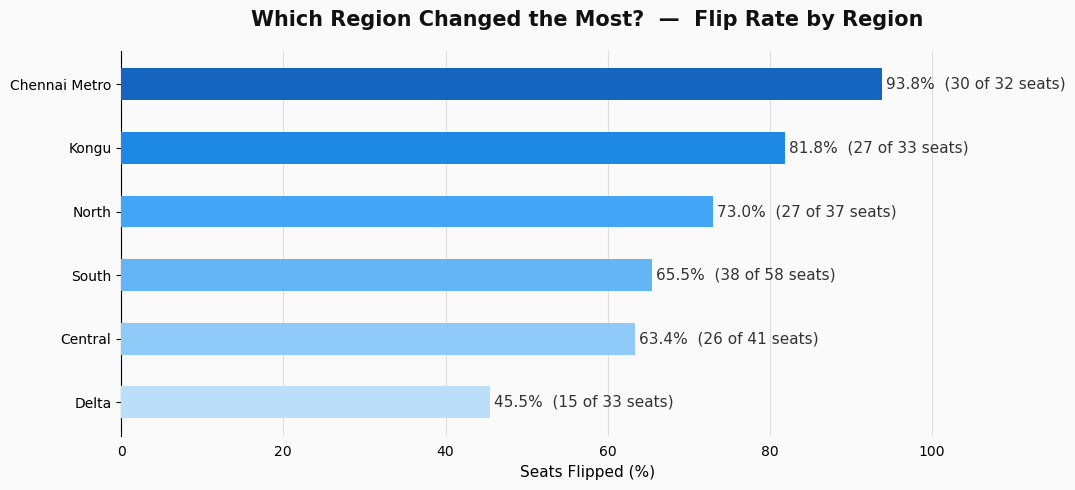

Chart 3 saved.


In [7]:
# Chart 3 — Flip rate by region

region_stats = master.groupby('region_master').agg(
    total   = ('flipped', 'count'),
    flipped = ('flipped', 'sum')
).reset_index()

region_stats['flip_rate'] = (region_stats['flipped'] / region_stats['total'] * 100).round(1)
region_stats = region_stats.sort_values('flip_rate', ascending=True)

# Color scale — darker = higher flip rate
colors = ['#BBDEFB','#90CAF9','#64B5F6','#42A5F5','#1E88E5','#1565C0']

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

bars = ax.barh(region_stats['region_master'], region_stats['flip_rate'],
               color=colors, height=0.5, zorder=3)

# Labels
for bar, (_, row) in zip(bars, region_stats.iterrows()):
    w = bar.get_width()
    ax.text(w + 0.5, bar.get_y() + bar.get_height()/2,
            f"{w}%  ({int(row['flipped'])} of {int(row['total'])} seats)",
            va='center', fontsize=11, color='#333333')

# Formatting
ax.set_xlim(0, 115)
ax.xaxis.grid(True, color='#DDDDDD', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.spines[['top','right','bottom']].set_visible(False)
ax.tick_params(bottom=False)
ax.set_xlabel('Seats Flipped (%)', fontsize=11)
ax.set_title('Which Region Changed the Most?  —  Flip Rate by Region',
             fontsize=15, fontweight='bold', color='#111111', pad=18)

plt.tight_layout()
plt.savefig('../charts/chart3_regional_flips.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved.")

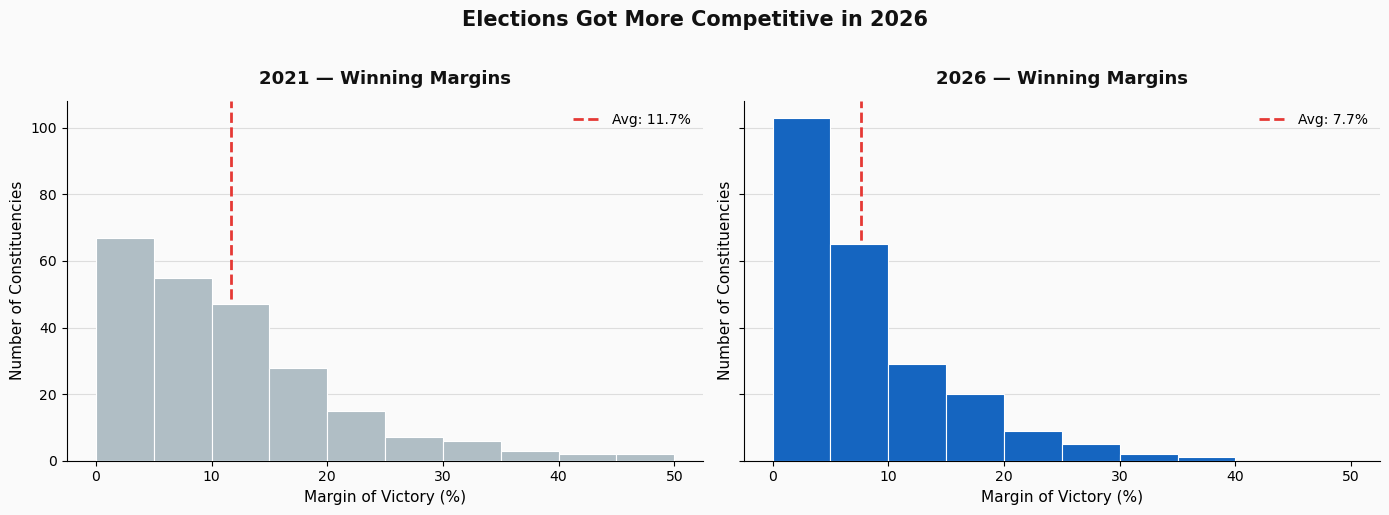

Chart 4 saved.


In [9]:
# Chart 4 — Margin % distribution comparison

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.patch.set_facecolor('#FAFAFA')

bins = np.arange(0, 55, 5)

for ax, data, year, color, avg in zip(
    axes,
    [master['mpct_21'], master['mpct_26']],
    ['2021', '2026'],
    ['#B0BEC5', '#1565C0'],
    [master['mpct_21'].mean(), master['mpct_26'].mean()]
):
    ax.set_facecolor('#FAFAFA')
    ax.hist(data, bins=bins, color=color, edgecolor='white', linewidth=0.8, zorder=3)
    ax.axvline(avg, color='#E53935', linewidth=2, linestyle='--', label=f'Avg: {avg:.1f}%')
    ax.set_title(f'{year} — Winning Margins', fontsize=13,
                 fontweight='bold', color='#111111', pad=12)
    ax.set_xlabel('Margin of Victory (%)', fontsize=11)
    ax.set_ylabel('Number of Constituencies', fontsize=11)
    ax.yaxis.grid(True, color='#DDDDDD', linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[['top','right']].set_visible(False)
    ax.legend(fontsize=10, frameon=False)

fig.suptitle('Elections Got More Competitive in 2026',
             fontsize=15, fontweight='bold', color='#111111', y=1.02)

plt.tight_layout()
plt.savefig('../charts/chart4_margin_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved.")

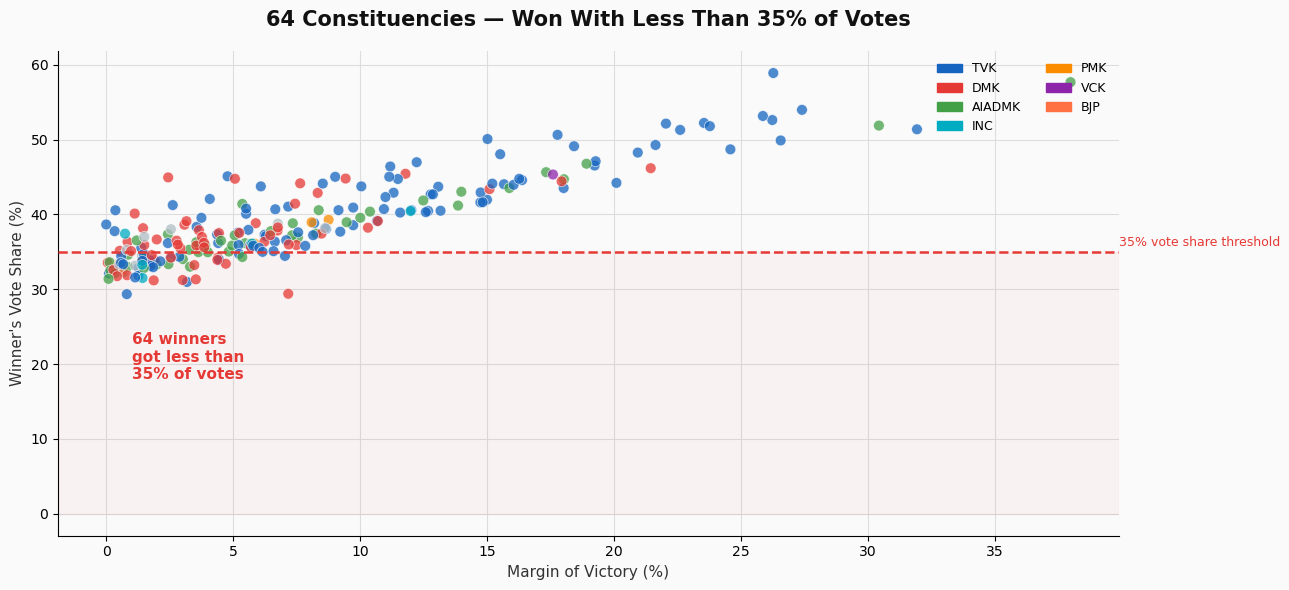

Chart 5 saved.


In [11]:
# Chart 5 — Vote share scatter with 35% threshold

# Merging winner party info into master
scatter = master[['ac_number','constituency','region_master','share_26','mpct_26','party_26']].copy()

# Party colors for the scatter
party_colors = {
    'TVK'    : '#1565C0',
    'DMK'    : '#E53935',
    'AIADMK' : '#43A047',
    'INC'    : '#00ACC1',
    'PMK'    : '#FB8C00',
    'VCK'    : '#8E24AA',
    'BJP'    : '#FF7043',
}
scatter['color'] = scatter['party_26'].map(party_colors).fillna('#B0BEC5')

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

ax.scatter(scatter['mpct_26'], scatter['share_26'],
           c=scatter['color'], alpha=0.75, s=60, zorder=3, edgecolors='white', linewidth=0.5)

# 35% threshold line
ax.axhline(35, color='#E53935', linewidth=1.8, linestyle='--', zorder=4)
ax.text(ax.get_xlim()[1] if ax.get_xlim()[1] > 1 else 40, 35.8,
        '35% vote share threshold', fontsize=9, color='#E53935')

# Shading the "thin win" zone
ax.axhspan(0, 35, alpha=0.04, color='#E53935')
ax.text(1, 18, f"{(scatter['share_26'] < 35).sum()} winners\ngot less than\n35% of votes",
        fontsize=11, color='#E53935', fontweight='bold')

# Legend
legend_handles = [mpatches.Patch(color=c, label=p) for p, c in party_colors.items()]
ax.legend(handles=legend_handles, fontsize=9, frameon=False,
          loc='upper right', ncol=2)

# Formatting
ax.set_xlabel('Margin of Victory (%)', fontsize=11, color='#333333')
ax.set_ylabel("Winner's Vote Share (%)", fontsize=11, color='#333333')
ax.set_title("64 Constituencies — Won With Less Than 35% of Votes",
             fontsize=15, fontweight='bold', color='#111111', pad=18)
ax.yaxis.grid(True, color='#DDDDDD', linewidth=0.8, zorder=0)
ax.xaxis.grid(True, color='#DDDDDD', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('../charts/chart5_vote_share_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 5 saved.")

In [13]:
# Confirming all 5 charts are saved
chart_files = os.listdir('../charts')
print(f"Charts saved: {len(chart_files)}")
for f in sorted(chart_files):
    print(f"  {f}")

Charts saved: 5
  chart1_seat_comparison.png
  chart2_flip_flows.png
  chart3_regional_flips.png
  chart4_margin_distribution.png
  chart5_vote_share_scatter.png
